# TS1

#### Rey Tomás 
#### APS

# Introducción 

Se analizarán distintas señales y estudiarán sus respuestas en el dominio de la frecuencia luego de aplicarles la transformada rápida de Fourier para poder comprobar cómo afecta en ese dominio el cambio de amplitudes, frecuencias y potencias en las señales entrantes, que en este caso serán senoidales y cuadradas. Adicionalmente, se estudiarán señales estocásticas (ruido con distintas distribuciones). 

In [42]:
"""
Created on Sun Aug 30 17:51:20 2026

@author: tomas
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

In [43]:
f=2000
N=1000

# Punto 1 

In [44]:
fs=20000
n=np.arange(0,N)
signal=np.sin(2*np.pi*(f/fs)*n)
freq=np.arange(0,fs,fs/N)

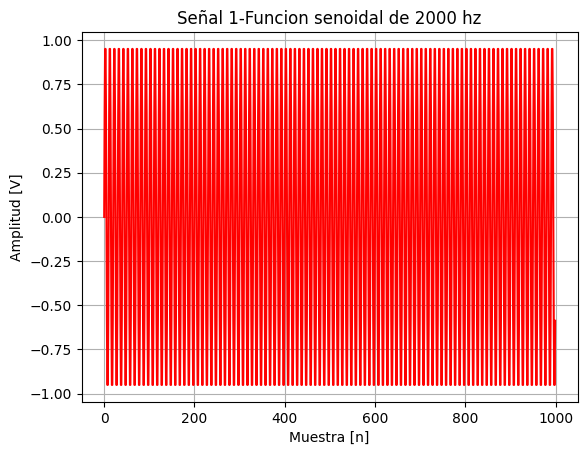

In [45]:
plt.plot(n,signal,color='red')
plt.title('Señal 1-Funcion senoidal de 2000 hz')
plt.xlabel('Muestra [n]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

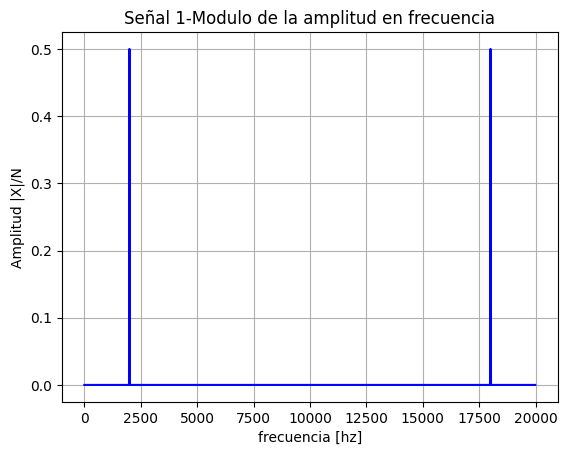

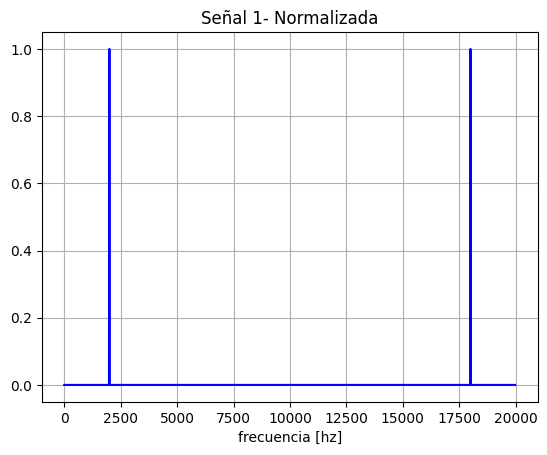

In [46]:
fft1=np.abs(np.fft.fft(signal))/N
fft1_norm=fft1/np.max(fft1)
plt.plot(freq,fft1,color='blue')
plt.title('Señal 1-Modulo de la amplitud en frecuencia')
plt.xlabel('frecuencia [hz]')
plt.ylabel('Amplitud |X|/N')
plt.grid('True')
plt.show()
plt.plot(freq,fft1_norm,color='blue')
plt.title('Señal 1- Normalizada')
plt.xlabel('frecuencia [hz]')
plt.grid('True')
plt.show() 

Se observa la transformada de Fourier en el dominio de la frecuencia para una señal seno, con dos deltas de Dirac que a f=2000hz y f=18000hz. Al graficar de 0 a 20000hz, las señales se veran espejadas a ambos lados de la frecuencia de Nyquist, es decir, fn=20000/2=10000hz, por eso la segunda delta aparece a 18000hz. Además, la amplitud de la señal espectral resultó ser de 0.5, lo que demuestra que en el dominio espectral la señal senoidal se divide en dos deltas de igual magnitud. 
En el gráfico normalizado, toda la señal se divide por su valor máximo en modulo, que es 0.5. Dado que la transformada de una senoidal es simplemente dos deltas de amplitud 0.5, y vale 0 para el resto de frecuencias, se observa dónde está el máximo de la señal de manera muy simple

# Punto 2

In [47]:
phi=np.pi/2
A=2
signal2=A*np.sin(2*np.pi*(f/fs)*n+phi)
fft2=np.abs(np.fft.fft(signal2))/N
fft2_norm=fft2/np.max(fft2)

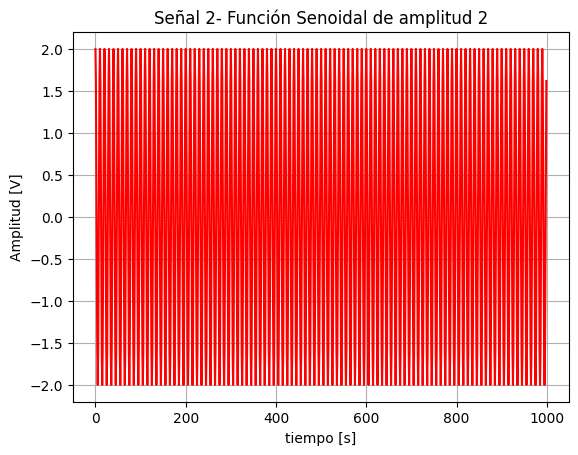

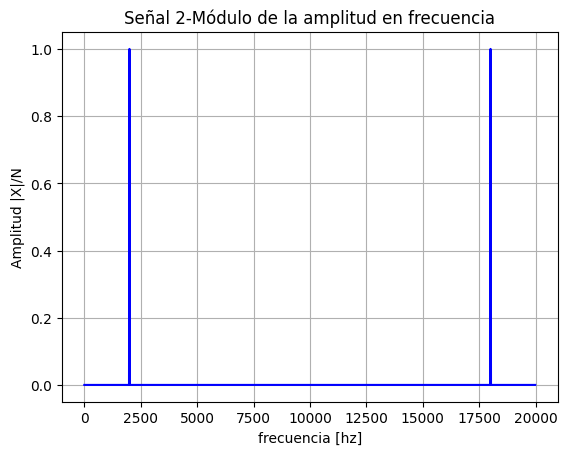

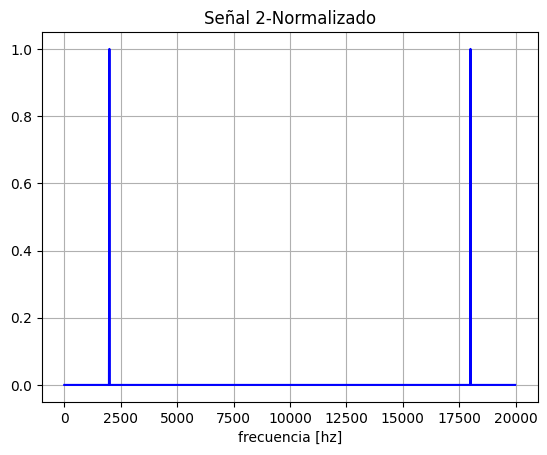

In [48]:
plt.plot(n,signal2,color='red')
plt.title('Señal 2- Función Senoidal de amplitud 2')
plt.xlabel('tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid('True')
plt.show()
plt.plot(freq,fft2,color='blue')
plt.title('Señal 2-Módulo de la amplitud en frecuencia')
plt.xlabel('frecuencia [hz]')
plt.ylabel('Amplitud |X|/N')
plt.grid('True')
plt.show()
plt.plot(freq,fft2_norm,color='blue')
plt.title('Señal 2-Normalizado')
plt.xlabel('frecuencia [hz]')
plt.grid('True')
plt.show()

Cambiar la fase de la senoidal no afectó en nada a su representación de módulo espectral, y las deltas aparecieron a las mismas frecuencias. El único cambio en el gráfico fue causado por aumentar la amplitud de la señal original. Se duplicó la amplitud de la señal de entrada, lo que duplicó la amplitud de su representación en frecuencia.
El gráfico normalizado no cambiará al cambiar la amplitud para este tipo de señales ya que la señal será siempre la máxima en 2 puntos y 0 para el resto.

# Punto 3

In [49]:
varianza=0.1
desv=np.sqrt(varianza)

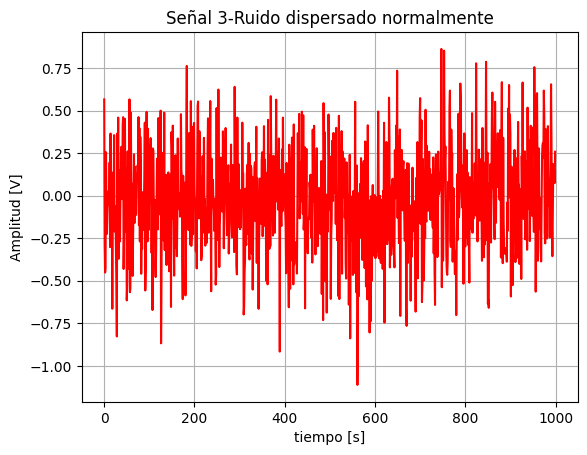

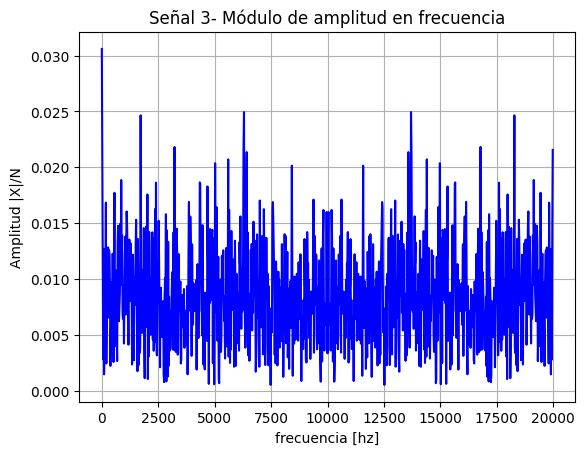

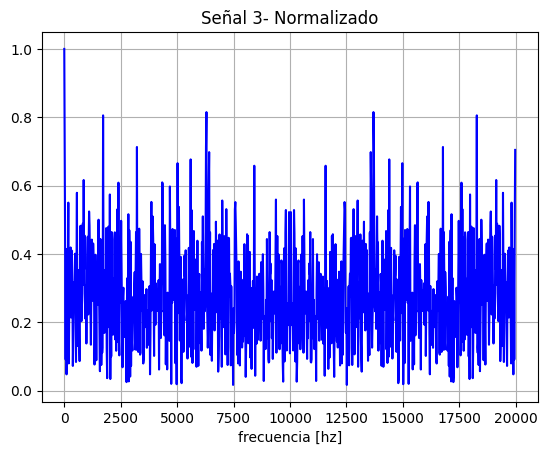

In [50]:
signal3 = np.random.normal(loc=0, scale=desv, size=N)
plt.plot(n,signal3,color='red')
plt.title('Señal 3-Ruido dispersado normalmente')
plt.xlabel('tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid('True')
plt.show()
abs_signal3=np.abs(np.fft.fft(signal3))/N
plt.plot(freq,abs_signal3,color='blue')
plt.title('Señal 3- Módulo de amplitud en frecuencia')
plt.xlabel('frecuencia [hz]')
plt.ylabel('Amplitud |X|/N')
plt.grid('True')
plt.show()
fft3_norm=abs_signal3/np.max(abs_signal3)
plt.plot (freq,fft3_norm,color='blue')
plt.title('Señal 3- Normalizado')
plt.xlabel('frecuencia [hz]')
plt.grid('True')
plt.show()

Se observa un "ruido blanco" uniformemente distribuido. No existe una frecuencia predominante, y normalizarlo no aporta mucha información extra. Ver la escala no normalizada nos permite ver que la amplitud por frecuencia es de muy baja potencia

# Punto 4

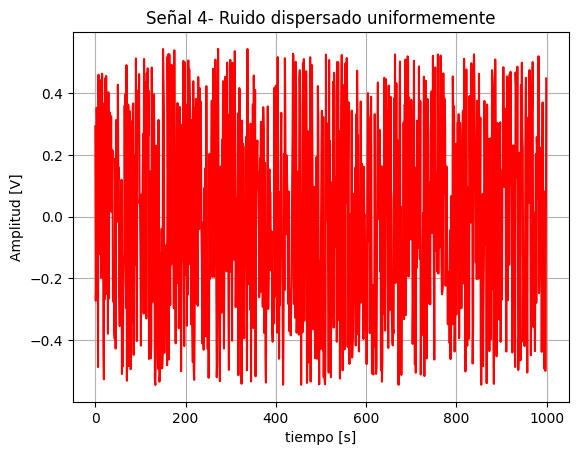

In [51]:
var=0.1
a=-np.sqrt(var*3)
b=-a
signal4=np.random.uniform(low=a, high=b, size=N)
plt.plot(n,signal4,color='red')
plt.title('Señal 4- Ruido dispersado uniformemente')
plt.xlabel('tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid('True')
plt.show()

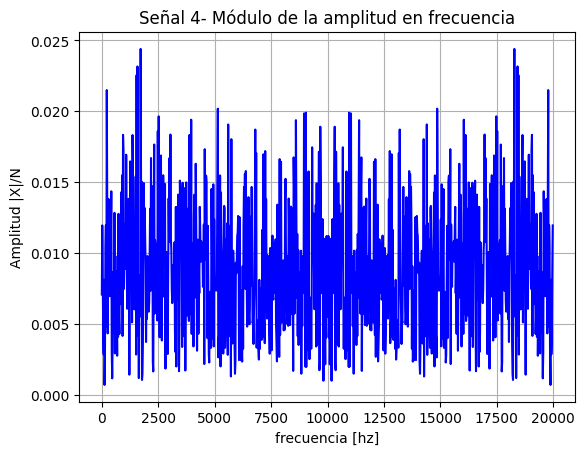

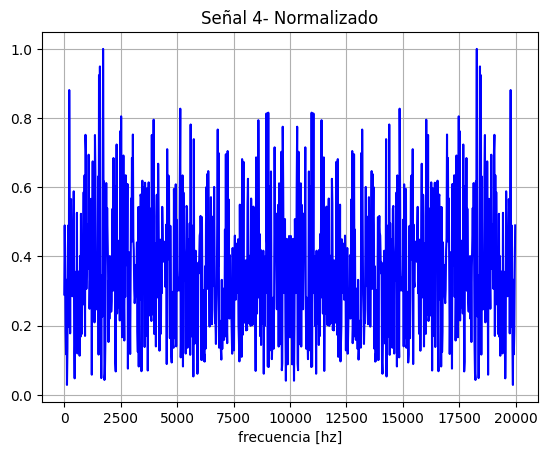

In [52]:
abs_signal4=np.abs(np.fft.fft(signal4))/N
plt.plot(freq,abs_signal4,color='blue')
plt.title('Señal 4- Módulo de la amplitud en frecuencia')
plt.xlabel('frecuencia [hz]')
plt.ylabel('Amplitud |X|/N')
plt.grid('True')
plt.show()
fft4_norm=abs_signal4/np.max(abs_signal4)
plt.plot(freq,fft4_norm,color='blue')
plt.title('Señal 4- Normalizado')
plt.xlabel('frecuencia [hz]')
plt.grid('True')
plt.show()

La distribución uniforme muestra un rango más acotado que la normal, sin embargo, en el dominio de la frecuencia, ambas muestran un comportamiento plano

# Punto 5

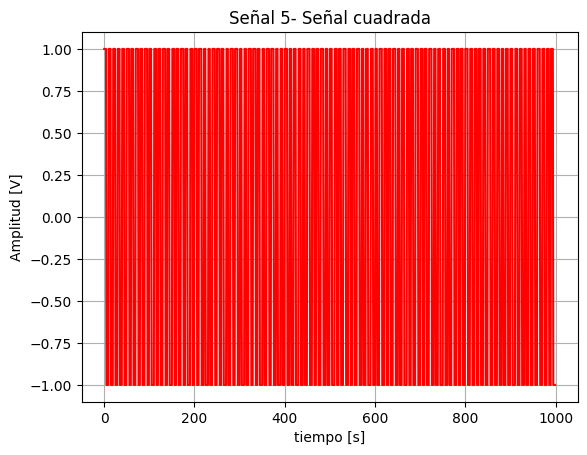

In [53]:
signal5=sig.square(2*np.pi*(f/fs)*n)
plt.plot(n,signal5,color='red')
plt.title('Señal 5- Señal cuadrada')
plt.xlabel('tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid('True')
plt.show()

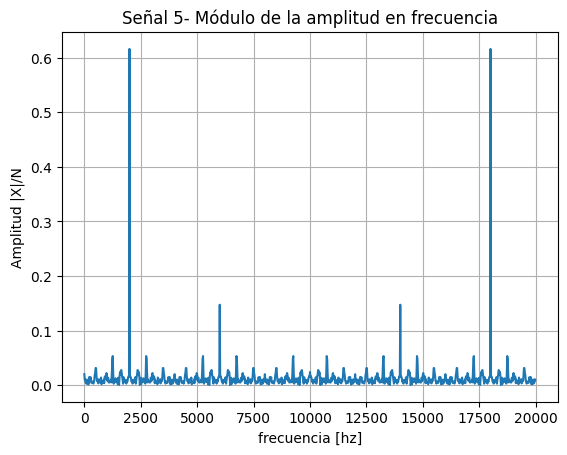

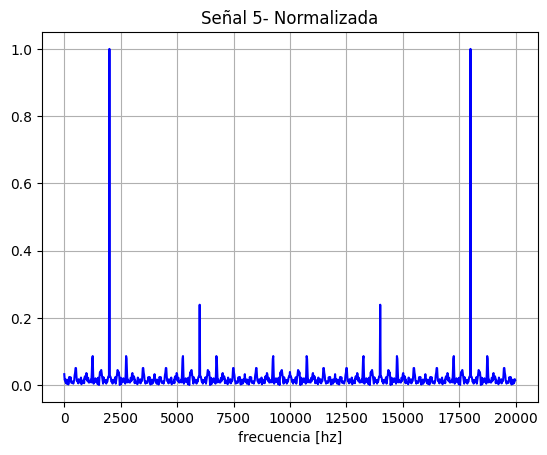

In [54]:
abs_signal5=np.abs(np.fft.fft(signal5))/N
plt.plot (freq,abs_signal5)
plt.title('Señal 5- Módulo de la amplitud en frecuencia')
plt.xlabel('frecuencia [hz]')
plt.ylabel('Amplitud |X|/N')
plt.grid('True')
plt.show()
fft5_norm=abs_signal5/np.max(abs_signal5)
plt.plot(freq,fft5_norm,color='blue')
plt.title('Señal 5- Normalizada')
plt.xlabel('frecuencia [hz]')
plt.grid('True')
plt.show()

Se un pico fundamental en f=2000hz, y luego un armónico de menor amplitud en el primer múltiplo impar de la frecuencia 3f=6000 hz, además de sus respectivos reflejos luego de la frecuencia de Nyquist

# Extra

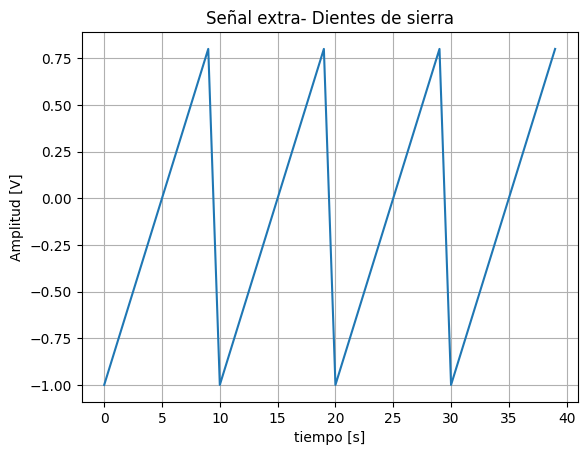

In [55]:
signal_saw=sig.sawtooth(2*np.pi*(f/fs)*n)
plt.plot(n[:40],signal_saw[:40])
plt.title('Señal extra- Dientes de sierra')
plt.xlabel('tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid('True')
plt.show()
abs_signal_saw=np.abs(np.fft.fft(signal_saw))/N

Se muestran solo los primeros 40 puntos para poder apreciar la forma

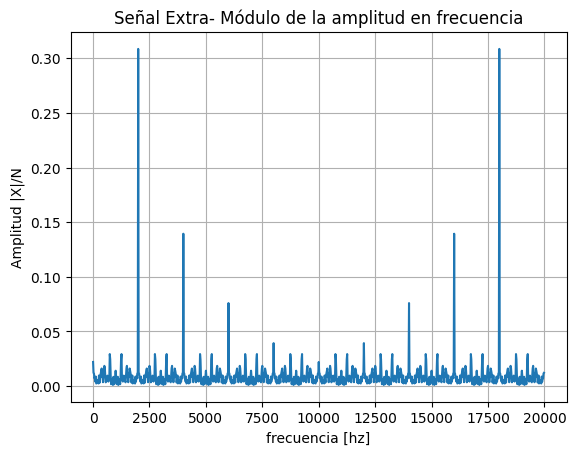

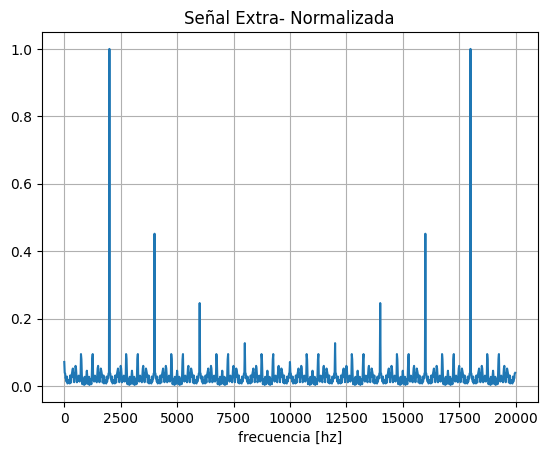

In [56]:
plt.plot(freq,abs_signal_saw)
plt.title('Señal Extra- Módulo de la amplitud en frecuencia')
plt.xlabel('frecuencia [hz]')
plt.ylabel('Amplitud |X|/N')
plt.grid('True')
plt.show()
fft_extra=abs_signal_saw/np.max(abs_signal_saw)
plt.plot(freq,fft_extra)
plt.title('Señal Extra- Normalizada')
plt.xlabel('frecuencia [hz]')
plt.grid('True')
plt.show()

A diferencia de la señal cuadrada, se observan todos los múltiplos enteros de la frecuencia fundamental, con un decaimiento en la intensidad.

# Potencia en el tiempo

In [57]:
P_tiempo1=np.mean(signal**2)
P_tiempo2=np.mean(signal2**2)
P_tiempo3=np.mean(signal3**2)
P_tiempo4=np.mean(signal4**2)   
P_tiempo5=np.mean(signal5**2)
P_tiempo_saw=np.mean(signal_saw**2)

In [58]:
print(f'Potencia en el tiempo de la señal 1: {P_tiempo1:.3}W' )
print(f'Potencia en el tiempo de la señal 2: {P_tiempo2:.3}W' )
print(f'Potencia en el tiempo de la señal 3: {P_tiempo3:.3}W' )
print(f'Potencia en el tiempo de la señal 4: {P_tiempo4:.3}W' )
print(f'Potencia en el tiempo de la señal 5: {P_tiempo5:.3}W' )
print(f'Potencia en el tiempo de la señal dientes de sierra: {P_tiempo_saw:.3}W' )  

Potencia en el tiempo de la señal 1: 0.5W
Potencia en el tiempo de la señal 2: 2.0W
Potencia en el tiempo de la señal 3: 0.0928W
Potencia en el tiempo de la señal 4: 0.0983W
Potencia en el tiempo de la señal 5: 1.0W
Potencia en el tiempo de la señal dientes de sierra: 0.34W


# Potencia en frecuencia

In [59]:
P_freq1=np.sum(fft1**2)
P_freq2=np.sum(fft2**2)
P_freq3=np.sum(abs_signal3**2)
P_freq4=np.sum(abs_signal4**2)
P_freq5=np.sum(abs_signal5**2)
P_freq_saw=np.sum(abs_signal_saw**2)

In [60]:
print(f'\n\nPotencia en frecuencia de la señal 1: {P_freq1:.3}W // {10*np.log10(P_freq1)} dB' )
print(f'Potencia en frecuencia de la señal 2: {P_freq2:.3}W // {10*np.log10(P_freq2)} dB' )
print(f'Potencia en frecuencia de la señal 3: {P_freq3:.3}W // {10*np.log10(P_freq3)} dB' )
print(f'Potencia en frecuencia de la señal 4: {P_freq4:.3}W // {10*np.log10(P_freq4)} dB' )
print(f'Potencia en frecuencia de la señal 5: {P_freq5:.3}W // {10*np.log10(P_freq5)} dB' )
print(f'Potencia en frecuencia de la señal sawtooth: {P_freq_saw:.3}W // {10*np.log10(P_freq_saw)} dB' )  



Potencia en frecuencia de la señal 1: 0.5W // -3.010299956639808 dB
Potencia en frecuencia de la señal 2: 2.0W // 3.0102999566398116 dB
Potencia en frecuencia de la señal 3: 0.0928W // -10.325558399652518 dB
Potencia en frecuencia de la señal 4: 0.0983W // -10.07487916216385 dB
Potencia en frecuencia de la señal 5: 1.0W // 0.0 dB
Potencia en frecuencia de la señal sawtooth: 0.34W // -4.68521082957746 dB


# Conclusiones

-En una señal senoidal, duplicar la amplitud cuadriplica la potencia, y desfasarla o correrla en el tiempo no afecta ni su amplitud ni su potencia. 
-Una señal determinística es aquella que en cualquier instante del tiempo tiene una expresión matemática que la define, y una estocástica es aquella descrita por una distribución de probabilidad.
-Normalizar una señal en el dominio de la frecuencia resulta útil para frecuencias determinísticas para establecer un nivel de referencia propio para el máximo de cada señal, pero no es tan útil para señales aleatorias como el ruido, donde los máximos no están anclados a una frecuencia física sino que nacen de la casuística de una distribución


# BONUS ejercicio 2

In [61]:
h=np.array([1, 0, 0, 0, -1])
x_c=np.array([1, 1, 1])

y_c=sig.convolve(x_c, h)
print("Resultado de la convolución y[n]:", y_c)

y_8=np.array([1, 1, 0, -1, -1, -1, 0, 1])
Y_k=np.fft.fft(y_8, n=8)

print("DFT de 8 puntos (FFT):", np.round(Y_k, 2)) 

Resultado de la convolución y[n]: [ 1  1  1  0 -1 -1 -1]
DFT de 8 puntos (FFT): [ 0.  +0.j  4.83+0.j  0.  +0.j -0.83+0.j  0.  +0.j -0.83+0.j  0.  +0.j
  4.83+0.j]
